In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bioviper import selector 

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

import pickle 

from studio_analysis_tools import *

In [219]:
#scores_path = "/Users/sam/Dropbox (Harvard University)/SpecificityStudio/all_scores.pkl"
scores_path = "/Users/sam/Downloads/all_scores_Jun2026_v1.pkl"

with open(scores_path, 'rb') as infile:
    all_scores = pickle.load(infile)
    
for prot,dataset in all_scores.items():
    if 'EVE' in dataset:
        dataset.loc[:,'EVE'] = -dataset['EVE']

## Boxplots

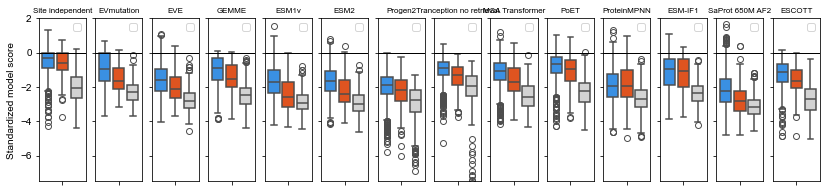

In [138]:
model_names = ['Site_independent', "EVmutation", "EVE", "GEMME", "ESM1v", "ESM2", "Progen2", "Tranception_no_retrieval", "MSA_Transformer", "PoET", "ProteinMPNN", "ESM-IF1", "SaProt_650M_AF2", "ESCOTT"]
data = all_scores['DLG4_HUMAN_Zarin_2024'].copy()
data.loc['WT'] = data.loc['WT'].fillna(0)
fig, ax = StudioBoxplots(data, model_names, standardize_to_wt=True);
for axis in ax:
    axis.set_ylim(-7.5,2)
    
plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 2/model_comparison_boxplots.pdf", bbox_inches='tight')

## Please ignore the next bit

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def ModelBoxplots(
    dataset,
    model_names,
    standardize_to_wt=True,
    model_category_map=None,
    category_order=None,
    within_category_gap=1.0,
    between_category_gap=2.0,
    palette=None,
    hue_order=None,
    figsize=None,
    box_width=0.22,
    linewidth=1.2,
    show_category_labels=True,
    show_category_separators=False,
):
    """
    Make grouped boxplots for model scores across specificity classes.

    Parameters
    ----------
    dataset : pd.DataFrame
        Must contain model score columns and a 'specificity_category' column.
    model_names : list of str
        Models to plot, in the desired within-category order.
    standardize_to_wt : bool
        If True, standardize relative to WT.
    model_category_map : dict or None
        Dict mapping model name -> model category.
    category_order : list or None
        Explicit order of model categories. If None, inferred from model_names.
    within_category_gap : float
        Distance between adjacent models in the same category.
    between_category_gap : float
        Distance between adjacent categories.
    palette : dict or None
        Colors for specificity categories.
    hue_order : list or None
        Order of specificity categories.
    figsize : tuple or None
        Figure size.
    box_width : float
        Width of each hue box.
    linewidth : float
        Line width for boxes.
    show_category_labels : bool
        Whether to draw category names above grouped models.
    show_category_separators : bool
        Whether to draw vertical separator lines between model categories.
    """

    if palette is None:
        palette = {
            "altered-specificity": "orangered",
            "native-specificity": "dodgerblue",
            "inactive": "lightgray",
            "other": "darkgray",
        }

    if hue_order is None:
        hue_order = ["native-specificity", "altered-specificity", "inactive"]

    # --- standardize model scores ---
    model_scores = dataset[model_names].copy()

    if standardize_to_wt:
        if "WT" not in model_scores.index:
            raise ValueError("standardize_to_wt=True but 'WT' is not present in dataset.index")
        denom = model_scores.std(axis=0).replace(0, np.nan)
        model_scores_standardized = (model_scores - model_scores.loc["WT"]) / denom
    else:
        denom = model_scores.std(axis=0).replace(0, np.nan)
        model_scores_standardized = (model_scores - model_scores.mean(axis=0)) / denom

    data = pd.concat(
        [model_scores_standardized, dataset["specificity_category"]],
        axis=1
    )

    # Replace inf with NaN explicitly
    data = data.replace([np.inf, -np.inf], np.nan)

    # --- model category handling ---
    if model_category_map is None:
        model_category_map = {m: "all models" for m in model_names}
    else:
        model_category_map = {m: model_category_map.get(m, "uncategorized") for m in model_names}

    if category_order is None:
        seen = []
        for m in model_names:
            cat = model_category_map[m]
            if cat not in seen:
                seen.append(cat)
        category_order = seen

    ordered_models = []
    for cat in category_order:
        ordered_models.extend([m for m in model_names if model_category_map[m] == cat])

    # --- compute model center positions ---
    model_positions = {}
    x = 0.0
    prev_cat = None
    for m in ordered_models:
        cat = model_category_map[m]
        if prev_cat is None:
            model_positions[m] = x
        else:
            if cat == prev_cat:
                x += within_category_gap
            else:
                x += between_category_gap
            model_positions[m] = x
        prev_cat = cat

    # --- figure ---
    if figsize is None:
        figsize = (max(5, 0.8 * len(model_names) + 1.5), 3.5)

    fig, ax = plt.subplots(figsize=figsize)

    # hue offsets around each model center
    n_hues = len(hue_order)
    offsets = np.linspace(-box_width, box_width, n_hues)

    # --- draw boxes manually ---
    for model in ordered_models:
        center = model_positions[model]

        any_boxes_drawn = False

        for j, spec_cat in enumerate(hue_order):
            vals = data.loc[data["specificity_category"] == spec_cat, model]
            vals = vals[np.isfinite(vals)].to_numpy()
            if len(vals) == 0:
                continue

            any_boxes_drawn = True
            pos = center + offsets[j]

            bp = ax.boxplot(
                [vals],
                positions=[pos],
                widths=box_width * 0.9,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color="black", linewidth=linewidth),
                boxprops=dict(linewidth=linewidth),
                whiskerprops=dict(linewidth=linewidth),
                capprops=dict(linewidth=linewidth),
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(palette.get(spec_cat, "gray"))
                patch.set_edgecolor("black")

    if not any_boxes_drawn:
        print(f"Warning: no finite values plotted for model '{model}'")

    # --- x axis ---
    ax.set_xticks([model_positions[m] for m in ordered_models])
    ax.set_xticklabels(
        [m.replace("_", " ") for m in ordered_models],
        rotation=45,
        ha="right",
        fontsize=8,
    )

    # --- reference line ---
    if standardize_to_wt:
        ax.axhline(0, ls="-", c="k", lw=1)

    ax.set_xlabel("")
    ax.set_ylabel("Standardized score")

    # --- legend ---
    legend_handles = [
        Patch(facecolor=palette[h], edgecolor="black", label=h)
        for h in hue_order
        if h in palette
    ]
    ax.legend(handles=legend_handles, frameon=False, title="")

    # --- category labels / separators ---
    if show_category_labels or show_category_separators:
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin

        for i, cat in enumerate(category_order):
            cat_models = [m for m in ordered_models if model_category_map[m] == cat]
            if not cat_models:
                continue

            xs = [model_positions[m] for m in cat_models]
            center = np.mean(xs)

            if show_category_labels:
                ax.text(
                    center,
                    ymax + 0.06 * yrange,
                    cat,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

            if show_category_separators and i < len(category_order) - 1:
                next_cat = category_order[i + 1]
                next_models = [m for m in ordered_models if model_category_map[m] == next_cat]
                if next_models:
                    boundary = (model_positions[cat_models[-1]] + model_positions[next_models[0]]) / 2
                    ax.axvline(boundary, color="0.85", lw=1, zorder=0)

        if show_category_labels:
            ax.set_ylim(ymin, ymax + 0.14 * yrange)
            

    fig.tight_layout()
    return fig, ax

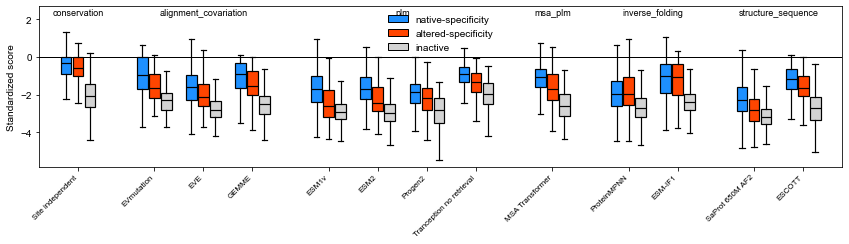

In [49]:
data = all_scores['DLG4_HUMAN_Zarin_2024'].copy()
data.loc['WT'] = data.loc['WT'].fillna(0)

model_names = ['Site_independent', "EVmutation", "EVE", "GEMME", "ESM1v", "ESM2", "Progen2", "Tranception_no_retrieval", "MSA_Transformer", "ProteinMPNN", "ESM-IF1", "SaProt_650M_AF2", "ESCOTT"]


fig, ax = ModelBoxplots(
    data,
    model_names,
    standardize_to_wt=True,
    model_category_map=model_classification,
    category_order=["conservation", "alignment_covariation", "plm", "msa_plm", "inverse_folding", "structure_sequence"],
    within_category_gap=0.9,
    between_category_gap=1.4,
)

## back at it

In [190]:
model_nicknames = {
    "Site_independent": "PSSM",
    "EVmutation": "EVmutation",
    "EVE": "EVE",
    "GEMME": "GEMME",
    "ESM1v": "ESM1v",
    "ESM2": "ESM2",
    "Progen2": "Progen2",
    "Tranception_no_retrieval": "Tranception",
    "MSA_Transformer": "MSAT",
    "PoET": "PoET",
    "ProteinMPNN": "ProteinMPNN",
    "ESM-IF1": "ESM-IF1",
    "SaProt_650M_AF2": "SaProt",
    "ESCOTT": "ESCOTT"
}

def label_scatterplot(df, ax, force_text=(1.5, 1.5), force_points=(1.5, 1.5), expand=(1.5, 1.5)):
    texts = []
    for xi, yi, label in zip(df['AUC'], df['specificity_score'], df.index):
        texts.append(
            ax.text(
                xi, yi, model_nicknames.get(label, label),
                fontsize=9
            )
        )

    adjust_text(
        texts,
        x=df['AUC'], y=df['specificity_score'],                  # repel from these points
        ax=ax,
        force_text=force_text,      # repel labels from each other more
        force_points=force_points,    # repel labels from points more
        expand=expand,
        arrowprops=None
    )
    
    for text, xi, yi in zip(texts, df['AUC'], df['specificity_score']):
        x_text, y_text = text.get_position()
        ax.plot([xi, x_text], [yi, y_text], color="gray", lw=0.7)

In [204]:
all_scores

{'DLG4_HUMAN_Zarin_2024':        Unnamed: 0     CRIPT      K-4A      K-4C      K-4D      K-4E      K-4F  \
 mutant                                                                          
 A41C        A343C  0.026520 -0.298913 -0.413703 -0.539565 -0.397802 -0.831110   
 A41D        A343D  0.069296 -0.378548 -0.469385 -0.628299 -0.389554 -0.820175   
 A41E        A343E  0.084897 -0.367243 -0.389051 -0.492823 -0.399576 -0.420478   
 A41F        A343F  0.005199       NaN       NaN -0.513716 -0.448537       NaN   
 A41G        A343G  0.083095 -0.296832 -0.238344 -0.377707 -0.292105 -0.363087   
 ...           ...       ...       ...       ...       ...       ...       ...   
 Y95S        Y397S       NaN -0.487962 -0.613474 -0.518967 -0.507763 -0.461042   
 Y95T        Y397T       NaN -0.529604 -0.633289 -0.392887 -0.498434 -0.522433   
 Y95V        Y397V       NaN -0.352307 -0.387348       NaN -0.444610 -0.724575   
 Y95W        Y397W       NaN -0.539345 -0.353026 -0.562085 -0.377603 -0.4

Empty DataFrame
Columns: [specificity_category, ESCOTT]
Index: []
Error with model scores for ESCOTT


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


No model scores for MSA_Transformer


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:141: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  wt_spearman = spearmanr(data_copy[model], data_copy[native_ligand])[0]
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be f

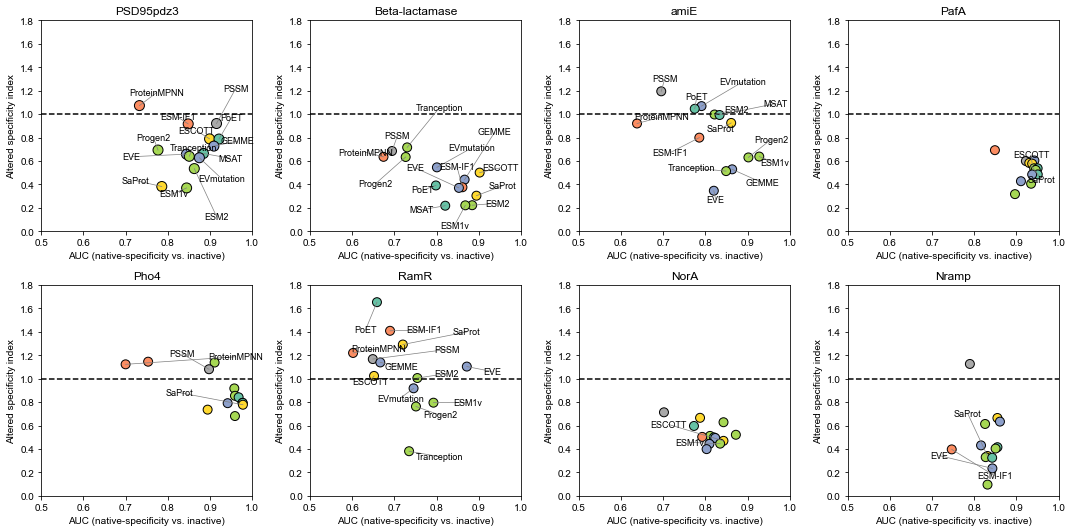

In [221]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
ax = ax.flatten()

all_scores['BLAT_ECOLX_Stiffler_2015']['n_subs'] = [mutant.count(',') + 1 if mutant!='WT' else 0 for mutant in all_scores['BLAT_ECOLX_Stiffler_2015'].index]
pdz_scores_df, n_pdz_spec_alter = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="AUC", ax=ax[0], ms=100, title="PSD95pdz3")
label_scatterplot(pdz_scores_df, ax[0])

amiE_scores_df, n_amiE_spec_alter = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[2], title="amiE")
label_scatterplot(amiE_scores_df, ax[2])

pafa_scores_df, n_pafa_spec_alter = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[3], title="PafA")
label_scatterplot(pafa_scores_df, ax[3])

blat_scores_df, n_blat_spec_alter = model_classification_plot(all_scores, 'BLAT_ECOLX_Stiffler_2015', x="AUC", ax=ax[1], title="Beta-lactamase")
label_scatterplot(blat_scores_df, ax[1])

ramR_scores_df, n_ramR_spec_alter = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", ax=ax[5], title="RamR")
label_scatterplot(ramR_scores_df, ax[5])

pho4_scores_df, n_pho4_spec_alter = model_classification_plot(all_scores, 'PHO4_YEAST_Aditham_2021', x="AUC", ax=ax[4], title="Pho4")
label_scatterplot(pho4_scores_df, ax[4], force_points=(0.5,0.5))

norA_scores_df, n_norA_spec_alter = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="AUC", ax=ax[6], title="NorA")
nramp_scores_df, n_nramp_spec_alter = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="AUC", ax=ax[7], title="Nramp")
label_scatterplot(norA_scores_df, ax[6])
label_scatterplot(nramp_scores_df, ax[7])

for axis in ax:
    axis.set_ylim(0,1.8)
    axis.set_xlim(0.5,1.0)
    
plt.tight_layout()

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 2/model_classification_scatterplots_v3_use_only_for_PafA_surgery.pdf", bbox_inches='tight')

In [218]:
np.any(np.isnan(list(all_scores['ALPH_ELIME_Markin_2021']['ProteinMPNN'])))

False

In [223]:
nramp_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
Site_independent,0.789695,1.125868,0.530537,darkgray
ESCOTT,0.854908,0.664536,0.653921,#ffd92f
GEMME,0.860904,0.633552,0.657638,#8da0cb
ESM2,0.825723,0.613367,0.613017,#a6d854
EVmutation,0.816132,0.430593,0.602103,#8da0cb
PoET,0.854953,0.415104,0.662962,#66c2a5
ESM1v,0.850604,0.403459,0.662655,#a6d854
ESM-IF1,0.746708,0.396240,0.469677,#fc8d62
SaProt_650M_AF2,0.831432,0.339950,0.635664,#ffd92f


In [213]:
pafa_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
GEMME,0.942465,0.604129,0.653423,#8da0cb
Site_independent,0.922310,0.599313,0.571635,darkgray
SaProt_650M_AF2,0.930406,0.583018,0.601894,#ffd92f
ESCOTT,0.937194,0.576797,0.657608,#ffd92f
ESM2,0.941959,0.537477,0.601899,#a6d854
PoET,0.950202,0.537035,0.657345,#66c2a5
ESM1v,0.945649,0.523079,0.650040,#a6d854
MSA_Transformer,0.950476,0.484880,0.711460,#66c2a5
EVE,0.937215,0.484360,0.661117,#8da0cb


In [201]:
pho4_scores_df.sort_values('specificity_score')

,AUC,specificity_score,wt_spearman,color
model,,,,
ESM2,0.958984,0.680959,-0.734427,#a6d854
ESCOTT,0.894245,0.735724,-0.686546,#ffd92f
SaProt_650M_AF2,0.977808,0.777639,-0.738720,#ffd92f
EVE,0.941680,0.790873,-0.772995,#8da0cb
PoET,0.977349,0.793413,-0.752230,#66c2a5
EVmutation,0.976737,0.793593,-0.761394,#8da0cb
MSA_Transformer,0.967707,0.841366,-0.702914,#66c2a5
ESM1v,0.958984,0.853852,-0.767675,#a6d854
Progen2,0.957453,0.916991,-0.710099,#a6d854


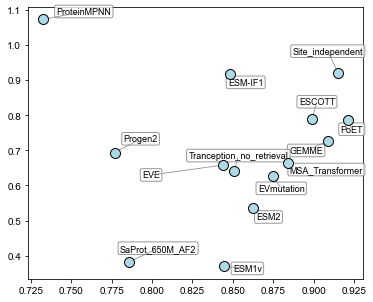

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(6,5))

ax.scatter(pdz_scores_df['AUC'], pdz_scores_df['specificity_score'], s=100, c='lightblue', edgecolors='k', zorder=5)

def label_scatterplot(df, ax):
    texts = []
    for xi, yi, label in zip(df['AUC'], df['specificity_score'], df.index):
        texts.append(
            ax.text(
                xi, yi, label,
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.5", alpha=0.8)
            )
        )

    adjust_text(
        texts,
        x=df['AUC'], y=df['specificity_score'],                  # repel from these points
        ax=ax,
        force_text=(2.0, 2.0),      # repel labels from each other more
        force_points=(2.5, 2.5),    # repel labels from points more
        expand=(1.5, 2.0),
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.7)
    )

In [155]:
ax.scatter(pdz_scores_df['AUC'], pdz_scores_df['specificity_score'], s=100, c='orangered', edgecolors='k', zorder=5, ax=ax[0])


TypeError: 'Axes' object is not subscriptable

In [154]:
ax

<Axes: >

In [152]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [209]:
all_aucs = pd.concat([pd.Series(df.AUC, name=protein) for protein,df in all_scores_dfs.items()], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)

In [20]:
all_scores_dfs = {'pdz':pdz_scores_df, 'amiE':amiE_scores_df, 'pafa':pafa_scores_df, 'pho4':pho4_scores_df, 'ramR':ramR_scores_df, 'norA':norA_scores_df, 'nramp':nramp_scores_df, 'blat': blat_scores_df}
all_specificity_scores = pd.concat([pd.Series(df.specificity_score, name=protein) for protein,df in all_scores_dfs.items()], axis=1).drop("ProteinMPNN")
all_specificity_scores['mean'] = all_specificity_scores.mean(axis=1)

(0.5, 1.0)

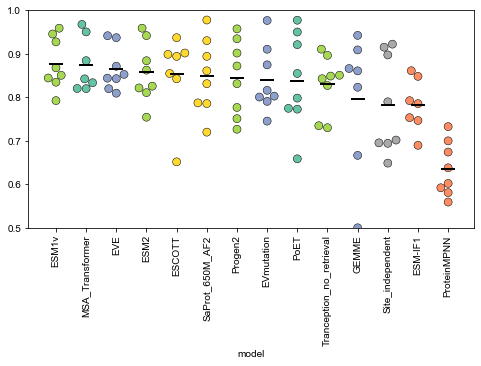

In [21]:
all_aucs = pd.concat([pd.Series(df.AUC, name=protein) for protein,df in all_scores_dfs.items()], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)

color_key = {'conservation': 'darkgray',
            'alignment_covariation':'#8da0cb',
                'plm':'#a6d854',
                'inverse_folding':'#fc8d62',
                'msa_plm':'#66c2a5',
                'structure_sequence':'#ffd92f'}


data = all_aucs.sort_values('mean', ascending=False).T

plt.figure(figsize=(8,4))
sns.swarmplot(data=data.drop('mean'), s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)

colors = [color_key[model_classification[x]] for x in data.columns]
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90);
plt.ylim(0.5, 1)

#plt.savefig('that_plot.pdf', bbox_inches='tight', dpi=300)

Text(65.0, 0.5, 'Altered specificity index')

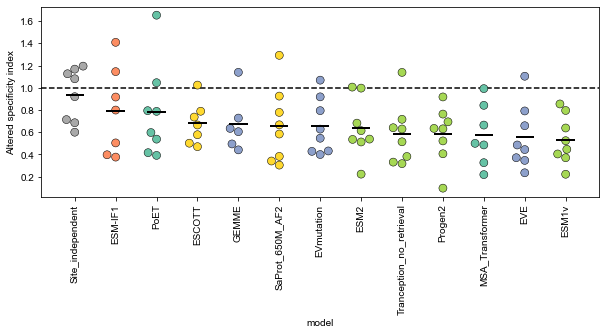

In [22]:
color_key = {'conservation': 'darkgray',
            'alignment_covariation':'#8da0cb',
                'plm':'#a6d854',
                'inverse_folding':'#fc8d62',
                'msa_plm':'#66c2a5',
                'structure_sequence':'#ffd92f'}

data = all_specificity_scores.sort_values('mean', ascending=False).T

plt.figure(figsize=(10,3.5))
sns.swarmplot(data=data.drop('mean'), s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] for x in data.columns]
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Altered specificity index")

#plt.savefig('ASI_plot.pdf', bbox_inches='tight', dpi=300)

In [11]:
np.log(N)

PSD95pdz3         5.455321
amiE              6.954639
PafA              3.178054
Beta-lactamase    4.663439
Pho4              3.663562
RamR              2.890372
NorA              6.084499
Nramp             2.639057
dtype: float64

In [ ]:
data = all_aucs.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

In [65]:
protein_color_map = {
    'pdz': "#6baed6",
    'amiE': "#e6550d",
    'blat': "#fd8d3c",
    'pafa': "#fdd0a2",
    'pho4': "#31a354",
    'ramR': "#a1d99b",
    'norA': "#756bb1",
    'nramp': "#bcbddc"
}

protein_color_map_v2 = {
    'pdz': "#6b6ecf",
    'amiE': "#637939",
    'blat': "#8ca252",
    'pafa': "#b5cf6b",
    'pho4': "#d6616b",
    'ramR': "#e7969c",
    'norA': "#ce6dbd",
    'nramp': "#bcbddc"
}

from matplotlib import cm
protein_color_map_v3 = {
    'pdz': cm.Pastel1(0.0),
    'amiE': cm.Pastel1(0.13),
    'blat': cm.Pastel1(0.26),
    'pafa': cm.Pastel1(0.39),
    'pho4': cm.Pastel1(0.52),
    'ramR': cm.Pastel1(0.65),
    'norA': cm.Pastel1(0.78),
    'nramp': cm.Pastel1(0.91)
}

protein_color_map_v4 = {
    'pdz': cm.Set3(0.0),
    'amiE': cm.Set3(0.13),
    'blat': cm.Set3(0.26),
    'pafa': cm.Set3(0.39),
    'pho4': cm.Set3(0.52),
    'ramR': cm.Set3(0.65),
    'norA': cm.Set3(0.78),
    'nramp': cm.Set3(0.91)
}

def map_cmap_to_proteins(protein_color_map, cmap):
    n = len(protein_color_map)
    colors = [cmap(i/n) for i in range(n)]
    return {protein: colors[i] for i, protein in enumerate(protein_color_map.keys())}

map_cmap_to_proteins(protein_color_map, cm.viridis)

{'pdz': (0.267004, 0.004874, 0.329415, 1.0),
 'amiE': (0.278826, 0.17549, 0.483397, 1.0),
 'blat': (0.229739, 0.322361, 0.545706, 1.0),
 'pafa': (0.172719, 0.448791, 0.557885, 1.0),
 'pho4': (0.127568, 0.566949, 0.550556, 1.0),
 'ramR': (0.157851, 0.683765, 0.501686, 1.0),
 'norA': (0.369214, 0.788888, 0.382914, 1.0),
 'nramp': (0.678489, 0.863742, 0.189503, 1.0)}

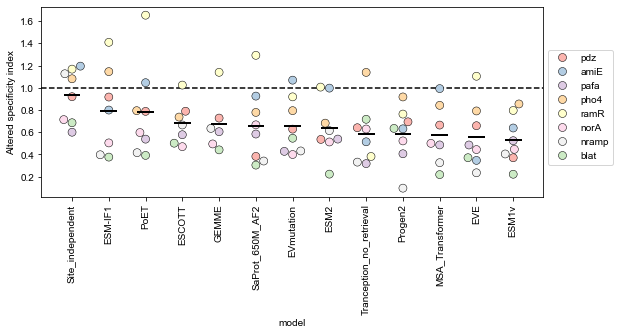

In [57]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data_long.loc[data_long['protein']!='mean']

sns.swarmplot(data=data_long, hue='protein', y='ASI', x='model', palette=protein_color_map_v3, edgecolor='k', linewidth=0.5, s=8,
              order=all_specificity_scores.sort_values('mean', ascending=False).index)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

data = all_specificity_scores.sort_values('mean', ascending=False).T
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90)
plt.ylabel("Altered specificity index")

plt.savefig('ASI_plot.pdf', bbox_inches='tight', dpi=300)

In [84]:
model_classification

{'Site_independent': 'conservation',
 'EVmutation': 'alignment_covariation',
 'EVE': 'alignment_covariation',
 'GEMME': 'alignment_covariation',
 'ESM1v': 'plm',
 'ESM2': 'plm',
 'Progen2': 'plm',
 'Tranception_no_retrieval': 'plm',
 'MSA_Transformer': 'msa_plm',
 'PoET': 'msa_plm',
 'ProteinMPNN': 'inverse_folding',
 'ESM-IF1': 'inverse_folding',
 'SaProt_650M_AF2': 'structure_sequence',
 'ESCOTT': 'structure_sequence'}

In [86]:
data_long

,protein,model,ASI,n_obs
0,pdz,Site_independent,0.919408,7.648529
1,amiE,Site_independent,1.194433,16.186414
2,pafa,Site_independent,0.599313,2.449490
3,pho4,Site_independent,1.080700,3.122499
4,ramR,Site_independent,1.167386,2.121320
...,...,...,...,...
111,pho4,ESCOTT,0.735724,3.122499
112,ramR,ESCOTT,1.023663,2.121320
113,norA,ESCOTT,0.469314,10.476163
114,nramp,ESCOTT,0.664536,1.870829


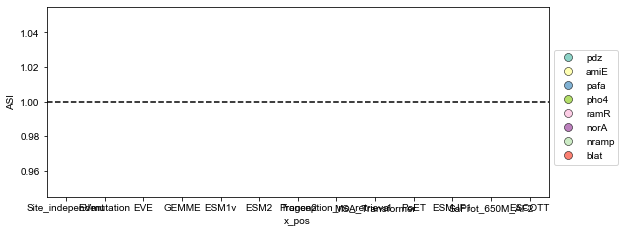

In [88]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data_long = data_long.loc[data_long['protein']!='mean']

pos_dict = get_custom_coords(model_classification, intra_gap=0.2, inter_gap=0.6)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='ASI', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.Set3), edgecolor='k', linewidth=0.5, s=8,
              order=[i for i in model_names if i!='ProteinMPNN'])
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

# data = all_specificity_scores.loc[[i for i in model_names if i!='ProteinMPNN']].T
# for i in range(data.shape[1]):
#     plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

# plt.xticks(rotation=90)
# plt.ylabel("Altered specificity index")

#plt.savefig('ASI_plot_model_order_Pastel1.pdf', bbox_inches='tight', dpi=300)

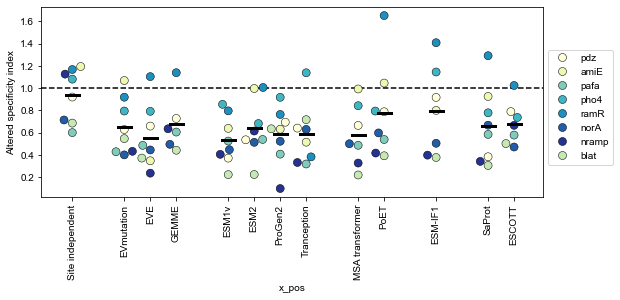

In [118]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='ASI', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.2

data = all_specificity_scores.loc[[i for i in model_names if i!='ProteinMPNN']].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("Altered specificity index")

plt.savefig('ASI_plot_model_order_grouped.pdf', bbox_inches='tight', dpi=300)

KeyError: "['ProteinMPNN'] not in index"

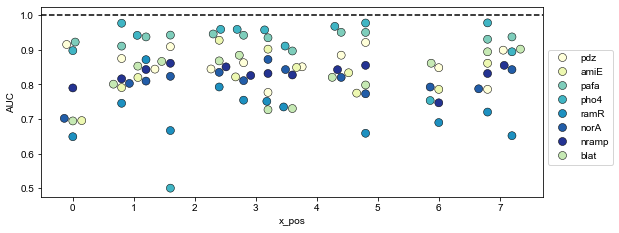

In [205]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.2

data = all_aucs.loc[model_names].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ProteinMPNN','ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("AUC (native-specificity vs inactive)")

#plt.savefig('AUC_plot_model_order_grouped.pdf', bbox_inches='tight', dpi=300)

In [121]:
data

model,Site_independent,EVmutation,EVE,GEMME,ESM1v,ESM2,Progen2,Tranception_no_retrieval,MSA_Transformer,PoET,ESM-IF1,SaProt_650M_AF2,ESCOTT
pdz,0.919408,0.627192,0.657916,0.726573,0.369434,0.534521,0.692888,0.639727,0.663624,0.787012,0.916132,0.381601,0.788251
amiE,1.194433,1.068132,0.345493,NaN,0.637310,0.996501,0.629862,0.513080,0.992143,1.045329,0.798924,0.924571,NaN
pafa,0.599313,0.426856,0.484360,0.604129,0.523079,0.537477,0.405289,0.316522,0.484880,0.537035,NaN,0.583018,0.576797
pho4,1.080700,0.793593,0.790873,NaN,0.853852,0.680959,0.916991,1.137907,0.841366,0.793413,1.145088,0.777639,0.735724
ramR,1.167386,0.917836,1.103493,1.138750,0.795089,1.005661,0.762697,0.380721,NaN,1.653272,1.408845,1.291763,1.023663
norA,0.712942,0.398559,0.443031,0.493769,0.445339,0.511523,0.521112,0.628192,0.498958,0.596346,0.503004,0.665930,0.469314
nramp,1.125868,0.430593,0.233954,0.633552,0.403459,0.613367,0.095562,0.330040,0.325029,0.415104,0.396240,0.339950,0.664536
blat,0.684760,0.545164,0.369784,0.440409,0.220836,0.221889,0.633612,0.715719,0.217593,0.390543,0.375272,0.303174,0.500486
mean,0.935601,0.650991,0.553613,0.672864,0.531049,0.637737,0.582252,0.582738,0.574799,0.777257,0.791929,0.658456,0.679824


In [122]:
help(data.melt)

Help on method melt in module pandas.core.frame:

melt(id_vars=None, value_vars=None, var_name=None, value_name: 'Hashable' = 'value', col_level: 'Level | None' = None, ignore_index: 'bool' = True) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Unpivot a DataFrame from wide to long format, optionally leaving identifiers set.
    
    This function is useful to massage a DataFrame into a format where one
    or more columns are identifier variables (`id_vars`), while all other
    columns, considered measured variables (`value_vars`), are "unpivoted" to
    the row axis, leaving just two non-identifier columns, 'variable' and
    'value'.
    
    Parameters
    ----------
    id_vars : scalar, tuple, list, or ndarray, optional
        Column(s) to use as identifier variables.
    value_vars : scalar, tuple, list, or ndarray, optional
        Column(s) to unpivot. If not specified, uses all columns that
        are not set as `id_vars`.
    var_name : scalar, default 

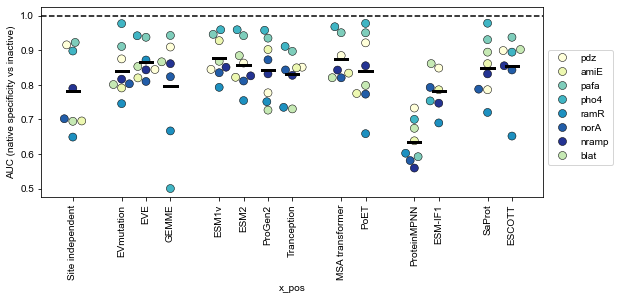

In [212]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data = all_aucs.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names], var_name='model', value_name='AUC')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.2

data = all_aucs.loc[[i for i in model_names]].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ProteinMPNN', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("AUC (native specificity vs inactive)")

plt.savefig('AUC_plot_model_order_grouped.pdf', bbox_inches='tight', dpi=300)

In [120]:
data_long

,protein,model,ASI,n_obs,x_pos
0,pdz,Site_independent,0.919408,7.648529,0.0
1,amiE,Site_independent,1.194433,16.186414,0.0
2,pafa,Site_independent,0.599313,2.449490,0.0
3,pho4,Site_independent,1.080700,3.122499,0.0
4,ramR,Site_independent,1.167386,2.121320,0.0
...,...,...,...,...,...
111,pho4,ESCOTT,0.735724,3.122499,6.8
112,ramR,ESCOTT,1.023663,2.121320,6.8
113,norA,ESCOTT,0.469314,10.476163,6.8
114,nramp,ESCOTT,0.664536,1.870829,6.8


ValueError: The palette dictionary is missing keys: {'GEMME', 'PoET', 'ESM-IF1', 'Site_independent', 'EVE', 'ESM2', 'Progen2', 'EVmutation', 'Tranception_no_retrieval', 'ESM1v', 'MSA_Transformer', 'SaProt_650M_AF2', 'ESCOTT'}

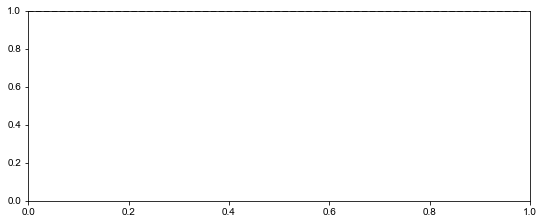

In [110]:
list(pos_dict.values())

In [94]:
pos_dict

{'Site_independent': 0.0,
 'EVmutation': 0.6,
 'EVE': 1.0,
 'GEMME': 1.4,
 'ESM1v': 2.0,
 'ESM2': 2.4,
 'Progen2': 2.8,
 'Tranception_no_retrieval': 3.1999999999999997,
 'MSA_Transformer': 3.8,
 'PoET': 4.2,
 'ProteinMPNN': 4.8,
 'ESM-IF1': 5.2,
 'SaProt_650M_AF2': 5.8,
 'ESCOTT': 6.2}

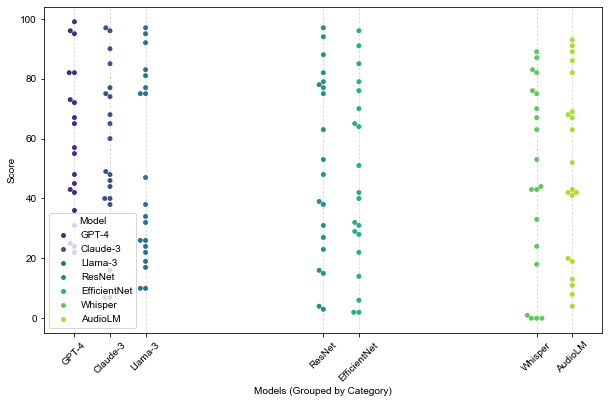

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def get_custom_coords(model_to_class, intra_gap=0.2, inter_gap=1.0):
    """
    Generates x-coordinates based on category groupings.
    """
    # Group models by their class
    from collections import defaultdict
    class_groups = defaultdict(list)
    for model, m_class in model_to_class.items():
        class_groups[m_class].append(model)
    
    coords = {}
    current_pos = 0.0
    
    for i, (m_class, models) in enumerate(class_groups.items()):
        # If not the first group, add the large inter-category gap
        if i > 0:
            current_pos += inter_gap
            
        for j, model in enumerate(models):
            # If not the first model in a group, add the small intra-category gap
            if j > 0:
                current_pos += intra_gap
            coords[model] = current_pos
            
    return coords

# --- Example Usage ---

# 1. Your mapping dictionary
model_mapping = {
    "GPT-4": "LLM", "Claude-3": "LLM", "Llama-3": "LLM",
    "ResNet": "CV", "EfficientNet": "CV",
    "Whisper": "Audio", "AudioLM": "Audio"
}

# 2. Generate coordinates
# Play with these numbers to get the visual density you want
pos_dict = get_custom_coords(model_mapping, intra_gap=0.3, inter_gap=1.5)

# 3. Create dummy data
data = []
for model in model_mapping:
    for _ in range(20):
        data.append({"Model": model, "Score": pd.Series(range(100)).sample(1).values[0]})
df = pd.DataFrame(data)

# 4. Map coordinates to the dataframe
df['x_pos'] = df['Model'].map(pos_dict)

# 5. Plotting
plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x='x_pos', y='Score', hue='Model', palette='viridis', native_scale=True)

# Set labels at the calculated positions
plt.xticks(list(pos_dict.values()), list(pos_dict.keys()), rotation=45)
plt.xlabel("Models (Grouped by Category)")
plt.grid(axis='x', linestyle='--', alpha=0.5) # Helps visualize the grouping
plt.show()

In [80]:
pos_dict

{'GPT-4': 0.0,
 'Claude-3': 0.3,
 'Llama-3': 0.6,
 'ResNet': 2.1,
 'EfficientNet': 2.4,
 'Whisper': 3.9,
 'AudioLM': 4.2}